In [ ]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt
import pickle
import statsmodels.api as sm
import matplotlib.ticker as mtick

In [2]:
key7 = 'afa544907ced4690b75ab2e31be66bc5af09caa9'
key8 = '774f340989704932aa5c85967cfacd8c1c06642d'
key = key8
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x2041c7efaa0 {name='workspace'}>

# Historical constituents of S&P 1500

I'm using S&P 1500 historical constituents to build the backtest. S&P 1500 represents 90% of US market cap, so it makes sense using it to avoid survorship bias, and to include all active tickers at each rebalancing period. This data was gather using Refinitiv API

In [3]:
const_2016to2026 = pd.read_csv(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\sp1500_const_2016-2026.csv")
const_2016to2026

,Unnamed: 0,Date,RIC
0,0,2016-01-01,AME.N
1,1,2016-01-01,CG.OQ
2,2,2016-01-01,AM.N
3,3,2016-01-01,ATGE.N
4,4,2016-01-01,ALKS.OQ
...,...,...,...
897320,897320,2025-12-22,TDW.N
897321,897321,2025-12-22,ALTR.OQ^C25
897322,897322,2025-12-22,DELL.N
897323,897323,2025-12-22,FTI.N


In [4]:
#convert to datetime
const_2016to2026['Date'] = pd.to_datetime(const_2016to2026['Date'])
const_2016to2026

,Unnamed: 0,Date,RIC
0,0,2016-01-01,AME.N
1,1,2016-01-01,CG.OQ
2,2,2016-01-01,AM.N
3,3,2016-01-01,ATGE.N
4,4,2016-01-01,ALKS.OQ
...,...,...,...
897320,897320,2025-12-22,TDW.N
897321,897321,2025-12-22,ALTR.OQ^C25
897322,897322,2025-12-22,DELL.N
897323,897323,2025-12-22,FTI.N


In [5]:
# dictionary (keys as dates and values as the lists of active constituents)
const_by_dates = (
    const_2016to2026
    .groupby('Date')['RIC'] # groups all rics by date
    .apply(list) # converts the rics to a list
    .to_dict() # converst all to dict, where the dates are keys
)

#rebal_dates = list(const_by_q.keys())
#rebal_dates

In [ ]:
# list of tickers
hist_const = set() #only unique values

for tickers in const_by_dates.values():
    hist_const.update(tickers)

hist_const = list(hist_const)
hist_const

In [7]:
len(hist_const)

1732

In [ ]:
const_by_dates.keys()

# Functions to gather data from Refinitiv

In [9]:
fields = [
    # Income Statement
    'TR.F.TotRevenue', 'TR.F.COGSTot', 'TR.F.GrossProfIndPropTot', 'TR.F.IncBefTax', 'TR.F.IncTax', 'TR.F.NetIncAfterTax', 'TR.F.IncAvailToComShr', 
    'TR.F.EBIT', 'TR.F.EBITDA',
    # Balance Sheet
    'TR.F.CashCashEquivTot', 'TR.F.TotCurrAssets', 'TR.F.TotAssets', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.TotCurrLiab', 'TR.F.DebtLTTot',
    'TR.F.ComEqParentShHold','TR.F.ComShrOutsTot', 'TR.F.NetDebt',
    # Cash Flow
    'TR.F.NetCashFlowOp'
]

def get_year_data(ticker, start_date, end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields,
        parameters={'Frq': 'FY', 'Period': 'FY0'},
        start=start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

fields_quarter = [
    #EV
    'TR.F.ComShrOutsTot', 'TR.F.DebtLTTot', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.PrefShHoldEq', 'TR.F.MinIntr', 'TR.F.CashCashEquivTot',
    #CFO and FCF
    'TR.F.NetCashFlowOp', 'TR.F.LeveredFOCF',
    #EBIT, revenue and eps
    'TR.F.EBIT', 'TR.F.TotRevenue', 'TR.F.EPSBasicExclExordItemsComTot'
    ]

def get_quarter_data(ticker, start_date, end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields_quarter,
        parameters={'Frq': 'FQ', 'Period': 'FQ0'},
        start = start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)


def get_daily_prices(ticker, start_date, end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.PriceClose'],
    interval= '1D',
    start = start_date,
    end = end_date)

    return df.fillna(0)

def get_sector(ticker):
    df = rd.get_data(
        universe=ticker,
        fields=['TR.TRBCEconomicSector']
    )

    return df.fillna(0)

Gather data of the sector. <br>
Then remove the tickers that are in Real Estate, Financials and Utilities economic sectors. <br>

In [11]:
tickers_sector = {}
error_tickers_sector = []

for ticker in hist_const:
    try:
        tickers_sector[ticker] = get_sector(ticker)['TRBC Economic Sector Name'].iloc[-1]
    except Exception as e:
        error_tickers_sector.append(ticker)
        print(f'Error with {ticker}: {e}')
        continue

In [12]:
print(error_tickers_sector)

[]


In [18]:
# run again to try to gather the data of error tickers
error_tickers = error_tickers_sector.copy()
error_tickers_sector = []

for ticker in error_tickers:
    try:
        tickers_sector[ticker] = get_sector(ticker)['TRBC Economic Sector Name'].iloc[-1]
    except Exception as e:
        error_tickers_sector.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [19]:
print(error_tickers_sector)

[]


In [20]:
len(tickers_sector.keys())

1732

In [21]:
# drop tickers that are in real estate, financials and utilities
drop_sectors = ['Real Estate', 'Financials', 'Utilities'] # exclude real estate, financials and utilities

for date, tickers in const_by_dates.items():
    const_by_dates[date] = [ticker for ticker in tickers
                              if tickers_sector[ticker] not in drop_sectors] 

In [ ]:
# list of tickers
hist_const = set() #only unique values

for tickers in const_by_dates.values():
    hist_const.update(tickers)

hist_const = list(hist_const)
print(len(hist_const))
hist_const

In [ ]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the q_data_dfs with fundamental data
tickers_data_year = {}
error_tickers_year = []

end_date = date.today()
start_date_year = '2009-01-01' # at least 5 years of historical data for quality composite

for ticker in hist_const:
    try:
        tickers_data_year[ticker] = get_year_data(ticker, start_date_year, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_year.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [567]:
print(error_tickers_year)

['OAS.OQ^J20', 'WW.OQ^E25']


In [ ]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the q_data_dfs with fundamental data
tickers_data_quarter = {}
error_tickers_quarter = []

end_date = date.today()
start_date_quarter = '2014-01-01' # at least 4 quarters of historical data for value composite

for ticker in hist_const:
    try:
        tickers_data_quarter[ticker] = get_quarter_data(ticker, start_date_quarter, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_quarter.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [ ]:
print(error_tickers_quarter)

['OAS.OQ^J20', 'WW.OQ^E25']


In [ ]:
#store daily prices for each ticker in a dictionary
tickers_daily_prices = {}
error_tickers_daily_prices = []

start_date_prices = '2015-01-01'

for ticker in hist_const:
    try:
        tickers_daily_prices[ticker] = get_daily_prices(ticker, start_date_prices, end_date)
    except Exception as e:
        error_tickers_daily_prices.append(ticker)
        print(f'Error fetching {ticker}: {e}')
        continue

In [ ]:
get_daily_prices('AAPL.OQ', start_date_prices, end_date)

In [585]:
print(error_tickers_daily_prices)

['DAY.N^B26', 'CIVI.N^A26', 'DCH.N']


In [ ]:
# run again to try to gather the data of error tickers
error_tickers = error_tickers_year.copy()
error_tickers_year = []

for ticker in error_tickers:
    try:
        tickers_data_year[ticker] = get_year_data(ticker, start_date_year, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_year.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

# run again to try to gather the data of error tickers
error_tickers = error_tickers_quarter.copy()
error_tickers_quarter = []

for ticker in error_tickers:
    try:
        tickers_data_quarter[ticker] = get_quarter_data(ticker, start_date_quarter, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_quarter.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

# run again to try to gather the data of error tickers
error_tickers = error_tickers_daily_prices.copy()
error_tickers_daily_prices = []

for ticker in error_tickers:
    try:
        tickers_daily_prices[ticker] = get_daily_prices(ticker, start_date_prices, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_daily_prices.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [ ]:
print(error_tickers_year)
print(error_tickers_quarter)
print(error_tickers_daily_prices)

In [ ]:
final_error_tickers = set(error_tickers_year + error_tickers_quarter + error_tickers_daily_prices)
final_error_tickers

In [592]:
with open('sp1500_fundamental_year_data_multifactor_model_v2', 'wb') as f:
    pickle.dump(tickers_data_year, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('sp1500_fundamental_quarter_data_multifactor_model_v2', 'wb') as f:
    pickle.dump(tickers_data_quarter, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('sp1500_daily_prices_data_multifactor_model_v2', 'wb') as f:
    pickle.dump(tickers_daily_prices, f, protocol=pickle.HIGHEST_PROTOCOL)

In [28]:
with open('sp1500_fundamental_year_data_multifactor_model_v2', 'rb') as f:
    tickers_data_year = pickle.load(f)

with open('sp1500_fundamental_quarter_data_multifactor_model_v2', 'rb') as f:
    tickers_data_quarter = pickle.load(f)

with open('sp1500_daily_prices_data_multifactor_model_v2', 'rb') as f:
    tickers_daily_prices = pickle.load(f)

In [ ]:
# Data gather from S&P website
sp_1500_price_data_df = pd.read_excel(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\SP1500_2016-2026_daily.xls")
sp_1500_price_data_df = sp_1500_price_data_df.rename(columns={'Date': 'date', 'S&P Composite 1500': 'last_close'})
sp_1500_price_data_df = sp_1500_price_data_df.set_index('date')
sp_1500_price_data_df

In [ ]:
# Data gather from S&P website
sp_500_price_data_df = pd.read_excel(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\SP500_daily_price_2016-2026.xls")
sp_500_price_data_df = sp_500_price_data_df.rename(columns={'Effective date': 'date', 'S&P 500': 'last_close'})
sp_500_price_data_df = sp_500_price_data_df.set_index('date')
sp_500_price_data_df

In [ ]:
# Fama French 5 factor data
fama_french_data_df = pd.read_csv(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\F-F_Research_Data_5_Factors_2x3_daily.csv")
fama_french_data_df["date"] = pd.to_datetime(fama_french_data_df["Unnamed: 0"].astype(str), format="%Y%m%d")
fama_french_data_df = fama_french_data_df.drop(columns='Unnamed: 0')
fama_french_data_df = fama_french_data_df.set_index('date')
fama_french_data_df

# SEC Filling Deadlines

Form 10-Q shall be filled 40 days after the end of the fiscal quarter for large accelerated filers and accelerated filers. 45 days for all other registrants. <br>

Form 10-K shall be filled 60 days after the end of the fiscal year for large accelerated filers, 75 days for accelerated filers and 90 days for non accelerated filers.

# SEC Filer Status Categories

Large accelerated filers: have a public float of $700 million or more <br>
Accelerated filers: have a public float of $75 million or more, but less than $700 million <br>
Non-accelerated filers: are typically companies with public float of less than $75 million; are companies that are neither accelerated filers nor large accelerated filers

In [29]:
for ticker, df in tickers_data_year.items():
    df['asof_date'] = df.index + pd.Timedelta(days=90)

for ticker, df in tickers_data_quarter.items():
    df['asof_date'] = df.index + pd.Timedelta(days=60)

# Rebalance dates

In [ ]:
start_rebalance_date = '2016-01-01'
end_rebalance_date = '2026-01-01'

rebalance_dates = pd.date_range(start=start_rebalance_date, end=end_rebalance_date, freq='QS') #quarter start

rebalance_dates

# Historical Data Filter



In [33]:
# creating a universe with all the tickers except the ones in final_error_tickers
no_errors_univ_by_q = {}

for date, tickers in const_by_dates.items():
    no_errors_univ_by_q[date] = [t for t in tickers if t not in final_error_tickers]

In [34]:
# Initial filter to only keep stocks with 3 years or more of historical data

data_available_univ_by_q = {}

for date in rebalance_dates:
    date_as_datetime = pd.to_datetime(date)
    date_as_str = date.strftime('%Y-%m-%d')
    list_tickers = []

    valid_dates = [d for d in no_errors_univ_by_q.keys() if d <= date]
    closest_date = max(valid_dates) if valid_dates else None

    for ticker in no_errors_univ_by_q[closest_date]:
        try:
            data_df = tickers_data_year[ticker].loc[tickers_data_year[ticker]['asof_date'] < date_as_datetime]
            n_rows = len(data_df)

            if n_rows >= 3:
                list_tickers.append(ticker)
            else:
                continue

        except Exception as e:
            print(f'Error with {ticker}: {e}')
    
    data_available_univ_by_q[date_as_str] = list_tickers

In [35]:
len(data_available_univ_by_q['2025-01-01'])

1133

In [ ]:
data_available_univ_by_q['2025-01-01']

# Quality signals

In [ ]:
#profitability
def get_delta_roa(ticker, ticker_data_year):
    # Calculate the delta roa of the last period vs the 5Y average
    try:
        df = ticker_data_year
        ni, assets = df['Income Available to Common Shares'], df['Total Assets']
        roa = ni / assets
        
        if len(roa) < 3:
            return None
        
        y = roa.tail(3)
        x = np.arange(len(y))
        cov = np.sum((x - x.mean()) * (y - y.mean()))
        var = np.sum((x - x.mean()) ** 2)
        slope = cov / var

        return slope
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def get_gp_assets_and_delta(ticker, ticker_data_year):
    try:
        df = ticker_data_year
        gross, assets = df['Gross Profit - Industrials/Property - Total'], df['Total Assets']
        gp_assets = gross / assets

        if len(gp_assets) < 3:
            return None
        
        y = gp_assets.tail(3)
        x = np.arange(len(y))
        cov = np.sum((x - x.mean()) * (y - y.mean()))
        var = np.sum((x - x.mean()) ** 2)
        slope = cov / var

        return y.mean(), slope

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
# earnings quality (accruals)

def get_acc_assets(ticker, ticker_data_year):
    try:
        df = ticker_data_year
        cfo, ni, assets = df['Net Cash Flow from Operating Activities'], df['Income Available to Common Shares'], df['Total Assets']
        acc = ni - cfo
        last_acc = acc.iloc[-1]
        if assets.iloc[-1] == 0 or assets.iloc[-2] == 0:
            return np.nan #return na if assets are 0 to avoid inf
        last_avg_assets = (assets[-1] + assets[-2]) / 2
        acc_a = last_acc / last_avg_assets
        return acc_a
      
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None


# leverage

def get_ndebt_ebitda(ticker, ticker_data_year):
    #if one negative ebitda i will override the ndebt_ebitda z score with the 20th percentile
    #if two negative ebitda i will override the ndebt_ebitda z score with the 5th percentile
    #if three negative i will just invalidate and drop stock
    try:
        df = ticker_data_year
        n_debt, ebitda = df['Net Debt'], df['Earnings before Interest Taxes Depreciation & Amortization']
        neg_count = (ebitda.tail(3) <= 0).sum()
        if neg_count == 1:
            return None, 'P'
        elif neg_count == 2:
            return None, 'HP'
        elif neg_count == 3:
            return None, 'INV'
        
        nd_clip = n_debt.tail(3).clip(lower=0) #make negative net debt into 0
        nd_ebitda = nd_clip / ebitda.tail(3)
        return nd_ebitda.tail(3).median(), 'VAL'

    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [38]:
df_googl = tickers_data_year['GOOGL.OQ']
print(get_delta_roa('GOOGL.OQ', df_googl))
get_gp_assets_and_delta('GOOGL.OQ', df_googl)

0.019319386613765074


(np.float64(0.4303555019232907), np.float64(-0.015638696118118883))

In [ ]:
quality_by_q = {}
errors_quality = []  #store errors for later review

for date in rebalance_dates:
    date_as_datetime = pd.to_datetime(date)
    date_as_str = date.strftime('%Y-%m-%d')
    rows = []
    
    for ticker in data_available_univ_by_q[date_as_str]:
        try:
            data_df = tickers_data_year[ticker].loc[tickers_data_year[ticker]['asof_date'] < date_as_datetime]
            n_rows = len(data_df)
            sector_ticker = tickers_sector[ticker]

            if n_rows >= 3: # the quality metrics need at least 5 years of data

                delta_roa = get_delta_roa(ticker, data_df)
                gp_a, gp_a_delta = get_gp_assets_and_delta(ticker, data_df)
                acc_a = get_acc_assets(ticker, data_df)
                ndebt_e, val = get_ndebt_ebitda(ticker, data_df)

                rows.append({
                    "ticker": ticker,
                    'economic_sector': sector_ticker,
                    'delta_roa': delta_roa,
                    'gp_assets': gp_a,
                    'delta_gp_assets': gp_a_delta,
                    "acc_assets": acc_a,
                    "ndebt_ebitda": ndebt_e,
                    'ndebt_e_val': val,
                })

        except Exception as e:
            errors_quality.append({
                "date": date,
                "ticker": ticker,
                "error_type": type(e).__name__,
                "error": str(e)})
            continue

    quality_by_q[date_as_str] = pd.DataFrame(rows)

errors_quality_df = pd.DataFrame(errors_quality)  # inspect what failed

In [102]:
quality_by_q['2016-01-01'].head(10)

,ticker,economic_sector,delta_roa,gp_assets,delta_gp_assets,acc_assets,ndebt_ebitda,ndebt_e_val,delta_roa_z,gp_assets_z,delta_gp_assets_z,acc_assets_z,ndebt_ebitda_z,quality_score_industry,quality_score,quality_p
0,AME.N,Industrials,0.001280,0.211813,-0.002517,-0.023011,1.294638,VAL,-0.005513,-0.587304,-0.178663,0.490927,0.013256,-0.354176,-0.647772,24.049217
1,ATGE.N,Academic & Educational Services,0.005540,0.485414,-0.046798,-0.032577,0.000000,VAL,0.253807,-0.392325,-0.152429,0.163185,-0.639602,-0.051509,-0.099556,50.223714
2,ALKS.OQ,Healthcare,0.000000,NaN,0.000000,NaN,NaN,P,0.012666,NaN,0.309924,NaN,0.594201,NaN,NaN,NaN
3,ANDE.OQ,Consumer Non-Cyclicals,0.004960,0.128195,-0.003127,0.051411,3.611730,VAL,0.346258,-1.207177,0.108279,1.396944,0.816312,-0.880068,-1.600314,3.803132
4,LIVN.OQ,Healthcare,0.008164,0.894731,-0.036368,0.002488,0.000000,VAL,0.170822,2.539247,-0.142155,1.071193,-0.879534,0.980234,1.769225,95.190157
5,LUV.N,Industrials,0.017500,0.507284,0.043431,-0.090202,0.000000,VAL,0.852338,0.697241,1.300704,-1.113365,-0.819310,0.880736,1.589005,94.071588
6,IAC.OQ,Technology,0.027806,0.469216,0.024114,-0.002161,0.000000,VAL,0.268726,0.880765,0.637294,0.976562,-0.676642,0.382924,0.687326,78.970917
7,DAR.N,Consumer Non-Cyclicals,-0.035855,0.156357,-0.068518,-0.050404,0.463480,VAL,-1.110135,-1.078552,-1.125989,-0.027280,-0.800415,-0.489494,-0.892873,16.554810
8,FFIV.OQ,Technology,0.016767,0.629362,0.067960,-0.142099,0.000000,VAL,0.129588,1.880042,1.596161,-1.122437,-0.676642,1.284408,2.320171,97.539150
9,HL.N,Basic Materials,-0.001407,0.057142,-0.033230,-0.029305,2.331921,VAL,0.199479,-1.427714,-0.630809,0.333999,0.508966,-0.782811,-1.424154,5.592841


In [ ]:
# cross sectional z scores
cols = ['delta_roa', 'gp_assets', 'delta_gp_assets', 'acc_assets', 'ndebt_ebitda']

for date, df in quality_by_q.items():
    df[cols] = df[cols].replace([pd.NA, np.inf, -np.inf], np.nan)
    # drop the rows where ebitda is negative in each of the last 3 years
    df = df[df["ndebt_e_val"] != "INV"].copy() #keeps all the stocks where ebitda is not negative in each of the last 3 years
    grp = df.groupby('economic_sector')


    for col in cols:
        # For each sector, compute the 1st and 99th percentile of col
        # transform() returns a series aligned to each row, so each row gets the percentile thresholds of its own sector
        low = grp[col].transform(lambda s: s.quantile(.01))
        high = grp[col].transform(lambda s: s.quantile(.99))
        col_clip = df[col].clip(lower=low, upper=high)

        # i should drop the rows that have negative ebitda for the whole 3 last years
        if col == 'ndebt_ebitda':
            #for net debt to ebitda, transform the P, HP into 80th and 95th percentile
            #higher net debt to ebitda is worse, so to penalize ill add the score of the 80th and 95th percentile
            q80 = grp[col].transform(lambda s: s.clip(s.quantile(.01), s.quantile(.99)).quantile(.8))
            q95 = grp[col].transform(lambda s: s.clip(s.quantile(.01), s.quantile(.99)).quantile(.95))
            q99 = grp[col].transform(lambda s: s.clip(s.quantile(.01), s.quantile(.99)).quantile(.99))

            col_adj = col_clip.copy()
            col_adj.loc[df['ndebt_e_val'] == 'P'] = q80.loc[df['ndebt_e_val'] == 'P']
            col_adj.loc[df['ndebt_e_val'] == 'HP'] = q95.loc[df['ndebt_e_val'] == 'HP']
            col_adj.loc[df['ndebt_e_val'] == 'INV'] = q99.loc[df['ndebt_e_val'] == 'INV']
    
        else:
           col_adj = col_clip

        temp_col = f'__{col}_adj'
        df[temp_col] = col_adj

        mu = df.groupby('economic_sector')[temp_col].transform('mean')
        sd = df.groupby('economic_sector')[temp_col].transform(lambda s: s.std())

        df[f'{col}_z'] = (df[temp_col] - mu) / sd

        df.drop(columns=[temp_col], inplace=True)

    # quality score industry
    df['quality_score_industry'] = (.4 * df['gp_assets_z'] # profitability
                                    + .1 * df['delta_gp_assets_z'] # profitability
                                    + .1 * df['delta_roa_z'] # profitability improvement
                                    - .2 * df['acc_assets_z'] # earnings quality
                                    - .2 * df['ndebt_ebitda_z']) # balance sheet risk
    
    # final quality score
    df['quality_score'] = (df['quality_score_industry'] - df['quality_score_industry'].mean()) / df['quality_score_industry'].std()
    df['quality_p'] = df['quality_score'].rank(pct=True) * 100

    quality_by_q[date] = df

quality_by_q

In [ ]:
quality_by_q['2022-01-01'].isna().sum()

In [103]:
quality_by_q['2023-01-01'].sort_values(by='quality_score', ascending=False).head(10)

,ticker,economic_sector,delta_roa,gp_assets,delta_gp_assets,acc_assets,ndebt_ebitda,ndebt_e_val,delta_roa_z,gp_assets_z,delta_gp_assets_z,acc_assets_z,ndebt_ebitda_z,quality_score_industry,quality_score,quality_p
569,WINA.OQ,Consumer Cyclicals,0.482103,1.933014,0.808596,-0.289354,0.201319,VAL,3.337818,2.878582,3.224747,-2.586281,-0.889415,2.502829,4.475011,100.000000
800,LPX.N,Basic Materials,0.315173,0.486388,0.364795,-0.050467,0.000000,VAL,3.694773,2.753321,3.998020,-0.616086,-1.502370,2.294299,4.102064,99.908341
28,ARCB.OQ,Industrials,0.038432,1.327884,0.051132,-0.056528,0.025556,VAL,1.688543,3.878144,1.763756,-0.767569,-1.105882,2.271178,4.060713,99.816682
934,PRG.N,Technology,0.070319,1.354239,0.562872,-0.001636,0.118271,VAL,0.741633,3.963132,2.913993,0.416393,-0.851543,2.037845,3.643408,99.725023
997,UPS.N,Industrials,0.054490,1.005178,0.031882,-0.032121,1.643632,VAL,2.446636,3.878144,1.195934,-0.206062,-0.115878,1.979902,3.539779,99.633364
339,ODFL.OQ,Industrials,0.030241,0.846242,0.036017,-0.038784,0.000000,VAL,1.301837,3.463501,1.317888,-0.359348,-1.121519,1.943546,3.474758,99.541705
214,SAIA.OQ,Industrials,0.028454,0.824127,-0.012341,-0.076226,0.146146,VAL,1.217497,3.330402,-0.108594,-1.220765,-1.032101,1.893624,3.385475,99.450046
1114,USNA.N,Consumer Non-Cyclicals,0.003595,1.603398,-0.006551,-0.007750,0.000000,VAL,-0.029362,3.744445,-0.252917,0.085988,-1.237370,1.699827,3.038875,99.358387
359,YELP.N,Technology,-0.000209,0.786730,0.006013,-0.156868,0.000000,VAL,-0.349751,2.916260,0.035219,-1.126181,-0.926616,1.545610,2.763065,99.266728
1035,CVLT.OQ,Technology,0.023941,0.697098,0.077525,-0.166901,0.000000,VAL,0.023961,2.374923,1.427866,-1.225883,-0.926616,1.525652,2.727370,99.175069


# Value signals

In [45]:
def get_last_price(ticker, tickers_daily_prices_df):
    try:
        df = tickers_daily_prices_df
        #last_price = df.iloc[-1]
        last_price = df['Price Close'].iloc[-1]
        return last_price
    
    except Exception as e:
        print(f'Error with price of {ticker}: {e}')
        return None

def get_enterprise_value(ticker, tickers_data_quarter, tickers_daily_prices_df):
    try:
        df = tickers_data_quarter
        last_price = get_last_price(ticker, tickers_daily_prices_df)
        st_debt, lt_debt, shares = df['Short-Term Debt & Current Portion of Long-Term Debt'], df['Debt - Long-Term - Total'], df['Common Shares - Outstanding - Total']
        prefered, minority, cash = df['Preferred Shareholders Equity'], df['Minority Interest'], df['Cash & Cash Equivalents - Total']

        market_cap = shares.iloc[-1] * last_price
        total_debt = st_debt.iloc[-1] + lt_debt.iloc[-1]
        ev = market_cap + total_debt + prefered.iloc[-1] + minority.iloc[-1] - cash.iloc[-1]
        return ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def get_ebit_ev(ticker, tickers_data_quarter, tickers_daily_prices_df):
    try:
        df = tickers_data_quarter
        df = df.tail(4)
        ev = get_enterprise_value(ticker, tickers_data_quarter, tickers_daily_prices_df)
        ebit = df['Earnings before Interest & Taxes (EBIT)']
        if ev < 0:
            return None
        ebit_ev = ebit.sum() / ev
        return ebit_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def get_fcf_ev(ticker, tickers_data_quarter, tickers_daily_prices_df):
    try:
        df = tickers_data_quarter
        df = df.tail(4)
        ev = get_enterprise_value(ticker, tickers_data_quarter,  tickers_daily_prices_df)
        fcf = df['Free Cash Flow']
        if ev < 0:
            return None
        fcf_ev = fcf.sum() / ev
        return fcf_ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def get_sales_p(ticker, tickers_data_quarter, tickers_daily_prices_df):
    try:
        df = tickers_data_quarter
        df = df.tail(4)
        last_price = get_last_price(ticker, tickers_daily_prices_df)
        sales, shares = df['Revenue from Business Activities - Total'], df['Common Shares - Outstanding - Total']
        #for some reason if the company fillings are recent some values (like shares outstanding) are 0 (probably a problem with the api)
        if shares.iloc[-1] == 0:
            sps = sales.sum() / float(shares.iloc[-2])
        else:
            sps = sales.sum() / float(shares.iloc[-1])
        sales_p = sps / last_price
        return sales_p
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def get_earnings_yield(ticker, tickers_data_quarter,  tickers_daily_prices_df):
    try:
        df = tickers_data_quarter
        df = df.tail(4)
        last_price = get_last_price(ticker, tickers_daily_prices_df)
        eps = df['EPS - Basic - excl Extraordinary Items, Common - Total']
        e_yield = eps.sum() / last_price
        return e_yield
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

In [ ]:
value_by_q = {}
errors_value = []  #store errors for later review

for date in rebalance_dates:
    date_as_datetime = pd.to_datetime(date)
    date_as_str = date.strftime('%Y-%m-%d')
    rows = []

    for ticker in data_available_univ_by_q[date_as_str]:
        try:
            data_df = tickers_data_quarter[ticker].loc[tickers_data_quarter[ticker]['asof_date'] < date_as_datetime]
            price_df = tickers_daily_prices[ticker].loc[tickers_daily_prices[ticker].index < date_as_datetime]
            n_rows = len(data_df)
            sector_ticker = tickers_sector[ticker]

            if n_rows >= 4: # the quality metrics need at least 1 year of data (4 quarters)
                ebit_ev = get_ebit_ev(ticker, data_df, price_df)
                fcf_ev = get_fcf_ev(ticker, data_df, price_df)
                sales_p = get_sales_p(ticker, data_df, price_df)
                earnings_y = get_earnings_yield(ticker, data_df, price_df)

                rows.append({
                    "ticker": ticker,
                    'economic_sector': sector_ticker,
                    'fcf_ev': fcf_ev,
                    'ebit_ev': ebit_ev,
                    'sales_p': sales_p, 
                    'earnings_y': earnings_y
                })

        except Exception as e:
            errors_value.append({
                "date": date,
                "ticker": ticker,
                "error_type": type(e).__name__,
                "error": str(e)})
            continue

    value_by_q[date_as_str] = pd.DataFrame(rows)

errors_value_df = pd.DataFrame(errors_value)  # inspect what failed

In [ ]:
value_by_q['2016-01-01'].isna().sum()

In [104]:
value_by_q['2016-01-01'].head(10)

,ticker,economic_sector,fcf_ev,ebit_ev,sales_p,earnings_y,ebit_ev_z,fcf_ev_z,sales_p_z,earnings_y_z,value_score_industry,value_score,value_p
0,AME.N,Industrials,0.043043,0.064585,0.314592,0.046809,-0.286433,0.014849,-0.831576,0.117918,-0.246311,-0.350927,32.329989
1,ATGE.N,Academic & Educational Services,0.069580,0.154109,1.174191,0.073081,0.599278,0.253276,-0.338809,0.480502,0.248562,0.358748,73.021182
2,ALKS.OQ,Healthcare,-0.006585,-0.014380,0.053836,-0.010719,-0.561406,-0.261328,-0.543607,-0.142857,-0.377299,-0.538772,22.630992
3,ANDE.OQ,Consumer Non-Cyclicals,-0.204658,0.071314,4.899203,0.065995,-0.073970,-2.804573,-0.032769,-0.118008,-0.757330,-1.083757,6.688963
4,LIVN.OQ,Healthcare,0.056055,0.055302,0.191556,0.011918,0.438367,0.700297,-0.426219,0.120234,0.208170,0.300823,70.680045
5,LUV.N,Industrials,0.045504,0.130257,0.695286,0.064090,1.285846,0.069063,-0.453950,0.380663,0.320406,0.461776,77.926421
6,IAC.OQ,Technology,0.223291,0.263057,3.610363,0.247684,3.445004,3.263250,2.548299,2.335678,2.898058,4.158273,99.777035
7,DAR.N,Consumer Non-Cyclicals,0.041360,0.044252,2.106284,0.036935,-0.332153,-0.016705,-0.099904,-0.124416,-0.143295,-0.203196,40.802676
8,FFIV.OQ,Technology,0.096325,0.086254,0.282303,0.052364,0.590441,0.979214,-0.521826,0.326923,0.343688,0.495164,79.487179
9,HL.N,Basic Materials,-0.022544,-0.027330,0.630687,-0.010291,-2.145329,-1.021537,-0.532422,-0.183001,-0.970572,-1.389559,5.128205


In [ ]:
# cross sectional z scores
cols = ['ebit_ev', 'fcf_ev', 'sales_p', 'earnings_y']

for date, df in value_by_q.items():
    df[cols] = df[cols].replace([pd.NA, np.inf, -np.inf], np.nan)
    grp = df.groupby('economic_sector')


    for col in cols:
        # For each sector, compute the 1st and 99th percentile of col
        # transform() returns a series aligned to each row, so each row gets the percentile thresholds of its own sector
        low = grp[col].transform(lambda s: s.quantile(.01))
        high = grp[col].transform(lambda s: s.quantile(.99))
        col_clip = df[col].clip(lower=low, upper=high)

        temp_col = f'__{col}_adj'
        df[temp_col] = col_clip

        mu = df.groupby('economic_sector')[temp_col].transform('mean')
        sd = df.groupby('economic_sector')[temp_col].transform(lambda s: s.std())

        df[f'{col}_z'] = (df[temp_col] - mu) / sd

        df.drop(columns=[temp_col], inplace=True)

    # value score industry
    df['value_score_industry'] = (df['ebit_ev_z'] + df['fcf_ev_z'] + df['sales_p_z'] + df['earnings_y_z']) / 4

    # final_value_score
    df['value_score'] = (df['value_score_industry'] - df['value_score_industry'].mean()) / df['value_score_industry'].std()
    df['value_p'] = df['value_score'].rank(pct=True) * 100
    
    value_by_q[date] = df

value_by_q

In [ ]:
value_by_q['2016-01-01'].isna().sum()

In [105]:
value_by_q['2016-01-01'].sort_values(by='value_score', ascending=False).head(10)

,ticker,economic_sector,fcf_ev,ebit_ev,sales_p,earnings_y,ebit_ev_z,fcf_ev_z,sales_p_z,earnings_y_z,value_score_industry,value_score,value_p
95,BRKb.N,Consumer Non-Cyclicals,0.800971,1.935257,954.073189,104.906090,7.311083,5.446684,7.996707,8.000467,7.188735,10.311345,100.000000
74,SNX.N,Technology,0.258329,0.193350,9.512574,0.139504,2.319547,3.893553,4.284196,1.318470,2.953941,4.238414,99.888517
6,IAC.OQ,Technology,0.223291,0.263057,3.610363,0.247684,3.445004,3.263250,2.548299,2.335678,2.898058,4.158273,99.777035
890,BKE.N,Consumer Cyclicals,0.180920,0.370295,1.479119,0.200286,3.893049,2.611757,0.245314,3.205405,2.488881,3.571491,99.665552
590,CXT.N,Technology,0.153343,0.263437,2.892766,0.227700,3.445372,2.004934,1.886318,2.322034,2.414664,3.465060,99.554069
834,ADEA.OQ,Technology,0.361139,0.474492,0.670436,0.314138,3.445372,4.004522,-0.163774,2.335678,2.405450,3.451845,99.442586
460,GME.N,Consumer Cyclicals,0.144715,0.212099,3.166830,0.132184,3.537016,2.539200,1.684421,1.752644,2.378320,3.412941,99.331104
777,CLF.N,Basic Materials,0.025329,0.111113,10.614073,1.587133,0.986284,-0.162714,4.159005,3.955036,2.234403,3.206554,99.219621
733,GBX.N,Industrials,0.073272,0.327190,2.762912,0.208784,3.975745,0.680655,1.597014,2.031807,2.071305,2.972664,99.108138
27,ARCB.OQ,Industrials,0.128242,0.151157,4.832502,0.095762,1.786215,1.891394,3.649926,0.862210,2.047436,2.938434,98.996656


# Final QV

In [52]:
final_qv = {}

for date in rebalance_dates:
    date_as_datetime = pd.to_datetime(date)
    date_as_str = date.strftime('%Y-%m-%d')
    
    try:
        final_qv[date_as_str] = (
            value_by_q[date_as_str][['ticker', 'economic_sector', 'value_score', 'value_p']]
            .merge(quality_by_q[date_as_str][['ticker', 'quality_score', 'quality_p']], on='ticker', how='outer')
        )

        final_qv[date_as_str]['final_qv_p'] = .5 * final_qv[date_as_str]['quality_p'] + .5 * final_qv[date_as_str]['value_p']

    except Exception as e:
        print(f'Error with {date_as_str}')
        continue

In [106]:
final_qv['2016-01-01'].sort_values(by='final_qv_p', ascending=False).head(10)

,ticker,economic_sector,value_score,value_p,quality_score,quality_p,final_qv_p
72,ARCB.OQ,Industrials,2.938434,98.996656,4.068336,99.888143,99.442399
563,MOH.N,Healthcare,2.479141,98.327759,2.777743,98.769575,98.548667
116,BKE.N,Consumer Cyclicals,3.571491,99.665552,1.713748,94.742729,97.204141
750,SAIA.OQ,Industrials,1.460993,94.091416,2.850571,98.993289,96.542352
346,GAP.N,Consumer Cyclicals,1.905234,96.321070,1.895606,95.973154,96.147112
364,GME.N,Consumer Cyclicals,3.412941,99.331104,1.261371,91.051454,95.191279
206,CPRI.N,Consumer Cyclicals,1.660927,95.206243,1.586199,93.959732,94.582987
187,CNC.N,Healthcare,1.588809,94.648829,1.446737,92.393736,93.521283
179,CLF.N,Basic Materials,3.206554,99.219621,0.985630,85.458613,92.339117
389,HCA.N,Healthcare,1.097992,90.078038,1.661540,94.407159,92.242598


# Selecting stocks

In [54]:
final_selected_stocks_qv = {}
final_selected_stocks_jg = {}

for date, df in final_qv.items():
    # compute cutoffs
    top_cutoff = df["final_qv_p"].quantile(0.8)
    bottom_cutoff = df["final_qv_p"].quantile(0.2)

    sel_stocks_qv = df[df['final_qv_p'] >= top_cutoff]
    sel_stocks_jg = df[df['final_qv_p'] <= bottom_cutoff]

    final_selected_stocks_qv[date] = sel_stocks_qv
    final_selected_stocks_jg[date] = sel_stocks_jg

In [55]:
print(len(final_selected_stocks_qv['2016-01-01']))
print(len(final_selected_stocks_jg['2016-01-01']))

171
171


In [ ]:
# weighting scheme (equal weighted)

for date, df in final_selected_stocks_qv.items():
    n_stocks = len(df)
    df['weight'] = 1 / n_stocks 


for date, df in final_selected_stocks_jg.items():
    n_stocks = len(df)
    df['weight'] = 1 / n_stocks 

In [107]:
final_selected_stocks_qv['2016-01-01'].sort_values(by='final_qv_p', ascending=False).head(10)

,ticker,economic_sector,value_score,value_p,quality_score,quality_p,final_qv_p,weight
72,ARCB.OQ,Industrials,2.938434,98.996656,4.068336,99.888143,99.442399,0.005848
563,MOH.N,Healthcare,2.479141,98.327759,2.777743,98.769575,98.548667,0.005848
116,BKE.N,Consumer Cyclicals,3.571491,99.665552,1.713748,94.742729,97.204141,0.005848
750,SAIA.OQ,Industrials,1.460993,94.091416,2.850571,98.993289,96.542352,0.005848
346,GAP.N,Consumer Cyclicals,1.905234,96.321070,1.895606,95.973154,96.147112,0.005848
364,GME.N,Consumer Cyclicals,3.412941,99.331104,1.261371,91.051454,95.191279,0.005848
206,CPRI.N,Consumer Cyclicals,1.660927,95.206243,1.586199,93.959732,94.582987,0.005848
187,CNC.N,Healthcare,1.588809,94.648829,1.446737,92.393736,93.521283,0.005848
179,CLF.N,Basic Materials,3.206554,99.219621,0.985630,85.458613,92.339117,0.005848
389,HCA.N,Healthcare,1.097992,90.078038,1.661540,94.407159,92.242598,0.005848


In [108]:
final_selected_stocks_jg['2016-01-01'].head(10)

,ticker,economic_sector,value_score,value_p,quality_score,quality_p,final_qv_p,weight
13,ACIW.OQ,Technology,-0.088294,49.498328,-1.104417,10.514541,30.006435,0.005848
23,ADP.OQ,Technology,-0.155805,44.593088,-0.838982,17.897092,31.245090,0.005848
29,AGYS.OQ,Technology,-1.725115,3.567447,-0.455254,30.872483,17.219965,0.005848
31,AIR.N,Industrials,-2.231153,2.006689,-1.591623,4.138702,3.072696,0.005848
47,AME.N,Industrials,-0.350927,32.329989,-0.647772,24.049217,28.189603,0.005848
51,AMPH.OQ,Healthcare,-0.595366,19.509476,-0.713383,21.700224,20.604850,0.005848
53,AMRX.OQ,Healthcare,-0.246734,38.684504,-0.588315,26.174497,32.429500,0.005848
57,ANDE.OQ,Consumer Non-Cyclicals,-1.083757,6.688963,-1.600314,3.803132,5.246048,0.005848
64,AOSL.OQ,Technology,-0.750494,13.489409,-0.306893,38.255034,25.872221,0.005848
66,APD.N,Basic Materials,-0.454300,26.755853,-0.647179,24.161074,25.458463,0.005848


# Backtest

In [ ]:
rebal_dates_backtest = list(rebalance_dates.copy())
today = pd.Timestamp.today().normalize()
rebal_dates_backtest.append(today)
rebal_dates_backtest

In [ ]:
rebal_dates_backtest

In [ ]:
rebal_dates_backtest = pd.DatetimeIndex(rebal_dates_backtest)

# keep only Q2 and Q4 starts
rebalance_dates_backtest_semi = rebal_dates_backtest[
    rebal_dates_backtest.quarter.isin([2, 4])
]

rebalance_dates_backtest_semi

In [ ]:
rebal_dates_backtest_semi = list(rebalance_dates_backtest_semi.copy())
today = pd.Timestamp.today().normalize()
rebal_dates_backtest_semi.append(today)
rebal_dates_backtest_semi

In [ ]:
# calculate daily returns of stocks
for ticker, prices in tickers_daily_prices.items():
    prices = prices.sort_index()
    prices['daily_return'] = prices['Price Close'].pct_change()
    prices['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
    tickers_daily_prices[ticker] = prices

In [66]:
daily_const_returns_qv = {}
error_tickers_backtest = set()

for start, end in zip(rebal_dates_backtest_semi, rebal_dates_backtest_semi[1:]):
    # this stock has been trading for the whole backtest period
    dates = tickers_daily_prices['AAPL.OQ'].loc[
        (tickers_daily_prices['AAPL.OQ'].index >= start) & (tickers_daily_prices['AAPL.OQ'].index < end)].index.tolist()

    rebal_trading_day = dates[0]
    start_str = start.strftime('%Y-%m-%d')
    tickers = list(final_selected_stocks_qv[start_str]['ticker'])

    date_progress = []

    for date in dates: # because im using the dates of tickers_daily_prices im starting before
        date_str = date.strftime('%Y-%m-%d')
        rows = []
        for ticker in tickers:
            try:
                # if date not in index, use 0, that means that the stock got delisted between rebalancing periods
                price = tickers_daily_prices[ticker]['Price Close'].get(date, 0) #loops up date, if found returns value if not returns 0
                daily_ret = tickers_daily_prices[ticker]['daily_return'].get(date, 0) #loops up date, if found returns value if not returns 0
                
                # if current date equals the date of rebalance then the constituent weight is the one defined above with the rules for weights
                if date == rebal_trading_day:
                    const_weight_open = final_selected_stocks_qv[start_str].loc[final_selected_stocks_qv[start_str]['ticker'] == ticker, 'weight'].item() #returns one value instead of pandas series
                # if the current date is not the rebalance date, then the weight will drift from target weights and its calculated 
                else:
                    const_weight_open = daily_const_returns_qv[date_progress[-1]].at[ticker, 'const_weight_close']

                rows.append({
                    'ticker': ticker,
                    'last_close': price,
                    'const_weight_open': const_weight_open,
                    'daily_return': daily_ret,
                    'weighted_return': daily_ret * const_weight_open,
                    'const_weight_close': const_weight_open * (1 + daily_ret),
                })

            except Exception as e:
                error_tickers_backtest.add(ticker)
                print(f'Error with {ticker}: {e}')
        
        daily_const_returns_qv[date_str] = pd.DataFrame(rows).set_index('ticker') #using ticker as index is faster
        
        new_port_weight = daily_const_returns_qv[date_str]['const_weight_close'].sum()
        daily_const_returns_qv[date_str]['const_weight_close'] = daily_const_returns_qv[date_str]['const_weight_close'] / new_port_weight

        date_progress.append(date_str)

In [67]:
daily_const_returns_jg = {}
error_tickers_backtest = set()

for start, end in zip(rebal_dates_backtest_semi, rebal_dates_backtest_semi[1:]):
    # this stock has been trading for the whole backtest period
    dates = tickers_daily_prices['AAPL.OQ'].loc[
        (tickers_daily_prices['AAPL.OQ'].index >= start) & (tickers_daily_prices['AAPL.OQ'].index < end)].index.tolist()

    rebal_trading_day = dates[0]
    start_str = start.strftime('%Y-%m-%d')
    tickers = list(final_selected_stocks_jg[start_str]['ticker'])

    date_progress = []

    for date in dates: # because im using the dates of tickers_daily_prices im starting before
        date_str = date.strftime('%Y-%m-%d')
        rows = []
        for ticker in tickers:
            try:
                # if date not in index, use 0, that means that the stock got delisted between rebalancing periods
                price = tickers_daily_prices[ticker]['Price Close'].get(date, 0) #loops up date, if found returns value if not returns 0
                daily_ret = tickers_daily_prices[ticker]['daily_return'].get(date, 0) #loops up date, if found returns value if not returns 0
                
                # if current date equals the date of rebalance then the constituent weight is the one defined above with the rules for weights
                if date == rebal_trading_day:
                    const_weight_open = final_selected_stocks_jg[start_str].loc[final_selected_stocks_jg[start_str]['ticker'] == ticker, 'weight'].item() #returns one value instead of pandas series
                # if the current date is not the rebalance date, then the weight will drift from target weights and its calculated 
                else:
                    const_weight_open = daily_const_returns_jg[date_progress[-1]].at[ticker, 'const_weight_close']

                rows.append({
                    'ticker': ticker,
                    'last_close': price,
                    'const_weight_open': const_weight_open,
                    'daily_return': daily_ret,
                    'weighted_return': daily_ret * const_weight_open,
                    'const_weight_close': const_weight_open * (1 + daily_ret),
                })

            except Exception as e:
                error_tickers_backtest.add(ticker)
                print(f'Error with {ticker}: {e}')
        
        daily_const_returns_jg[date_str] = pd.DataFrame(rows).set_index('ticker') #using ticker as index is faster
        
        new_port_weight = daily_const_returns_jg[date_str]['const_weight_close'].sum()
        daily_const_returns_jg[date_str]['const_weight_close'] = daily_const_returns_jg[date_str]['const_weight_close'] / new_port_weight

        date_progress.append(date_str)

In [109]:
daily_const_returns_qv['2016-04-01'].head(10)

,last_close,const_weight_open,daily_return,weighted_return,const_weight_close
ticker,,,,,
AAL.OQ,39.520000,0.00578,-0.036333,-0.000210,0.005554
AAPL.OQ,27.497500,0.00578,0.009175,0.000053,0.005816
ABBV.N,57.420000,0.00578,0.005252,0.000030,0.005793
ACN.N,116.350000,0.00578,0.008232,0.000048,0.005811
ADEA.OQ,8.175633,0.00578,-0.002903,-0.000017,0.005746
ADUS.OQ,17.180000,0.00578,-0.000582,-0.000003,0.005760
AEIS.OQ,35.010000,0.00578,0.006324,0.000037,0.005800
AEO.N,16.610000,0.00578,-0.003599,-0.000021,0.005742
AIT.N,44.120000,0.00578,0.016590,0.000096,0.005859


In [69]:
portfolio_daily_return_qv = {}
portfolio_daily_return_jg = {}

for date, df in daily_const_returns_qv.items():
    port_return = df['weighted_return'].sum()
    portfolio_daily_return_qv[date] = port_return

for date, df in daily_const_returns_jg.items():
    port_return = df['weighted_return'].sum()
    portfolio_daily_return_jg[date] = port_return

In [ ]:
portfolio_daily_return_qv_df = pd.DataFrame.from_dict(portfolio_daily_return_qv, orient='index', columns=['return'])
portfolio_daily_return_qv_df.index = pd.to_datetime(portfolio_daily_return_qv_df.index)

portfolio_daily_return_qv_df['cum_return'] = (1 + portfolio_daily_return_qv_df['return']).cumprod()
portfolio_daily_return_qv_df['port_level'] = 100 * portfolio_daily_return_qv_df['cum_return'] # the starting index level is 100

In [110]:
portfolio_daily_return_qv_df.head(10)

,return,cum_return,port_level
2016-04-01,0.002993,1.002993,100.299326
2016-04-04,-0.008127,0.994842,99.484199
2016-04-05,-0.009629,0.985262,98.526241
2016-04-06,0.009728,0.994847,99.484736
2016-04-07,-0.014094,0.980826,98.082604
2016-04-08,0.002597,0.983373,98.337307
2016-04-11,-0.003921,0.979517,97.951701
2016-04-12,0.009382,0.988707,98.870719
2016-04-13,0.020024,1.008505,100.850542
2016-04-14,-0.004458,1.004010,100.400954


In [ ]:
portfolio_daily_return_jg_df = pd.DataFrame.from_dict(portfolio_daily_return_jg, orient='index', columns=['return'])
portfolio_daily_return_jg_df.index = pd.to_datetime(portfolio_daily_return_jg_df.index)

portfolio_daily_return_jg_df['cum_return'] = (1 + portfolio_daily_return_jg_df['return']).cumprod()
portfolio_daily_return_jg_df['port_level'] = 100 * portfolio_daily_return_jg_df['cum_return'] # the starting index level is 100

In [111]:
portfolio_daily_return_jg_df.head(10)

,return,cum_return,port_level
2016-04-01,0.003690,1.003690,100.368963
2016-04-04,-0.011765,0.991881,99.188083
2016-04-05,-0.009826,0.982135,98.213458
2016-04-06,0.012881,0.994785,99.478512
2016-04-07,-0.009969,0.984869,98.486860
2016-04-08,0.008790,0.993526,99.352562
2016-04-11,-0.000319,0.993209,99.320903
2016-04-12,0.012803,1.005925,100.592508
2016-04-13,0.018468,1.024503,102.450265
2016-04-14,-0.003476,1.020942,102.094161


In [ ]:
starting_date = portfolio_daily_return_qv_df.index[0]
sp_1500 = sp_1500_price_data_df.loc[sp_1500_price_data_df.index > starting_date]

sp_1500 = sp_1500.sort_index()
sp_1500['daily_return'] = sp_1500['last_close'].pct_change()
sp_1500['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
sp_1500['cum_return'] = (1 + sp_1500['daily_return']).cumprod()

In [113]:
sp_1500.head()

,last_close,daily_return,cum_return
date,,,
2016-04-04,476.66,NaN,NaN
2016-04-05,471.79,-0.010217,0.989783
2016-04-06,476.69,0.010386,1.000063
2016-04-07,470.92,-0.012104,0.987958
2016-04-08,472.39,0.003122,0.991042


In [ ]:
sp_500 = sp_500_price_data_df.loc[sp_500_price_data_df.index > starting_date]

sp_500 = sp_500.sort_index()
sp_500['daily_return'] = sp_500['last_close'].pct_change()
sp_500['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
sp_500['cum_return'] = (1 + sp_500['daily_return']).cumprod()

In [114]:
sp_1500.head()

,last_close,daily_return,cum_return
date,,,
2016-04-04,476.66,NaN,NaN
2016-04-05,471.79,-0.010217,0.989783
2016-04-06,476.69,0.010386,1.000063
2016-04-07,470.92,-0.012104,0.987958
2016-04-08,472.39,0.003122,0.991042


In [115]:
fama_french_5 = fama_french_data_df.loc[fama_french_data_df.index > starting_date]
fama_french_5.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,
2016-04-04,-0.41,-0.29,-0.78,-0.25,-0.20,0.0
2016-04-05,-0.94,-0.18,-0.38,0.09,0.17,0.0
2016-04-06,1.14,0.09,-0.76,-0.54,-0.65,0.0
2016-04-07,-1.23,-0.10,-0.38,-0.01,0.19,0.0
2016-04-08,0.29,0.13,0.68,0.37,0.31,0.0


In [75]:
# calendar year performance
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

perf_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    port_year_qv = portfolio_daily_return_qv_df.loc[(portfolio_daily_return_qv_df.index >= start_d) & (portfolio_daily_return_qv_df.index <= end_d)]
    port_return_qv = (port_year_qv['port_level'].iloc[-1] / port_year_qv['port_level'].iloc[0]) - 1
    port_std_qv = port_year_qv['return'].std() * np.sqrt(252)

    port_year_jg = portfolio_daily_return_jg_df.loc[(portfolio_daily_return_jg_df.index >= start_d) & (portfolio_daily_return_jg_df.index <= end_d)]
    port_return_jg = (port_year_jg['port_level'].iloc[-1] / port_year_jg['port_level'].iloc[0]) - 1
    port_std_jg = port_year_jg['return'].std() * np.sqrt(252)

    index_year = sp_500.loc[(sp_500.index >= start_d) & (sp_500.index <= end_d)]
    index_return = (index_year['last_close'].iloc[-1] / index_year['last_close'].iloc[0]) - 1
    index_std = index_year['daily_return'].std() * np.sqrt(252)

    perf_by_year.append({
        'year': year,
        'return_port_qv': f'{round(port_return_qv * 100, 2)}%',
        'return_port_jg': f'{round(port_return_jg * 100, 2)}%',
        'return_sp500': f'{round(index_return * 100, 2)}%',
        'std_port_qv': f'{round(port_std_qv * 100, 2)}%',
        'std_port_jg': f'{round(port_std_jg * 100, 2)}%',
        'std_500': f'{round(index_std * 100, 2)}%',
        'return_to_volatility_port_qv': round((port_return_qv / port_std_qv), 2),
        'return_to_volatility_port_jg': round((port_return_jg / port_std_jg), 2),
        'return_to_volatility_sp500': round((index_return / index_std), 2)
    })

perf_by_year_df = pd.DataFrame(perf_by_year)

perf_by_year_df

,year,return_port_qv,return_port_jg,return_sp500,std_port_qv,std_port_jg,std_500,return_to_volatility_port_qv,return_to_volatility_port_jg,return_to_volatility_sp500
0,2016,17.52%,21.24%,8.36%,15.59%,16.36%,10.89%,1.12,1.30,0.77
1,2017,19.33%,24.99%,18.42%,11.16%,11.03%,6.69%,1.73,2.27,2.75
2,2018,-8.0%,-12.96%,-7.01%,17.58%,18.42%,17.05%,-0.46,-0.70,-0.41
3,2019,18.02%,33.38%,28.71%,16.8%,15.67%,12.46%,1.07,2.13,2.30
4,2020,13.81%,30.55%,15.29%,42.45%,44.56%,34.43%,0.33,0.69,0.44
5,2021,45.95%,29.76%,28.79%,21.04%,22.14%,13.1%,2.18,1.34,2.20
6,2022,-11.47%,-11.99%,-19.95%,26.65%,28.91%,24.17%,-0.43,-0.41,-0.83
7,2023,23.93%,17.88%,24.73%,17.34%,18.5%,13.09%,1.38,0.97,1.89
8,2024,6.94%,14.68%,24.01%,16.25%,17.94%,12.65%,0.43,0.82,1.90
9,2025,8.48%,15.05%,16.65%,22.41%,24.29%,18.75%,0.38,0.62,0.89


Annualized Performance (CAGR)

For the 10-year backtest, the annualized return (CAGR) measures the compounded average annual growth rate of each portfolio over different time horizons.

Over 1 year, the QV portfolio returned 12.37%, the JG portfolio returned 26.0%, and the S&P 500 returned 14.07%.

Over 3 years, the QV portfolio returned 10.09%, the JG portfolio returned 15.54%, and the S&P 500 returned 17.97%.

Over 5 years, the QV portfolio returned 12.0%, the JG portfolio returned 12.53%, and the S&P 500 returned 11.83%.

Over 10 years, the QV portfolio returned 13.35%, the JG portfolio returned 16.96%, and the S&P 500 returned 12.58%.

In [ ]:
# cagr

end_d = portfolio_daily_return_qv_df.index.max()

years = [1, 3, 5, 10]

cagr = []

for year in years:
    start_d = end_d - pd.DateOffset(years=year)
    port_year_qv = portfolio_daily_return_qv_df.loc[(portfolio_daily_return_qv_df.index >= start_d) & (portfolio_daily_return_qv_df.index <= end_d)]
    total_growth_qv = (1 + port_year_qv['return']).prod()
    ann_return_qv = total_growth_qv ** (1 / year) - 1

    port_year_jg = portfolio_daily_return_jg_df.loc[(portfolio_daily_return_jg_df.index >= start_d) & (portfolio_daily_return_jg_df.index <= end_d)]
    total_growth_jg = (1 + port_year_jg['return']).prod()
    ann_return_jg = total_growth_jg ** (1 / year) - 1

    index_year = sp_1500.loc[(sp_1500.index >= start_d) & (sp_1500.index <= end_d)]
    total_growth_i = (1 + index_year['daily_return']).prod()
    ann_return_i = total_growth_i ** (1 / year) - 1

    cagr.append({
        'year': f'{year}Y',
        'ann_return_qv': f'{round(ann_return_qv * 100, 2)}%',
        'ann_return_jg': f'{round(ann_return_jg * 100, 2)}%',
        'ann_return_sp1500': f'{round(ann_return_i * 100, 2)}%'
    })

cagr_df = pd.DataFrame(cagr)
cagr_df

,year,ann_return_qv,ann_return_jg,ann_return_sp1500
0,1Y,12.37%,26.0%,14.07%
1,3Y,10.09%,15.54%,17.97%
2,5Y,12.0%,12.53%,11.83%
3,10Y,13.35%,16.96%,12.58%


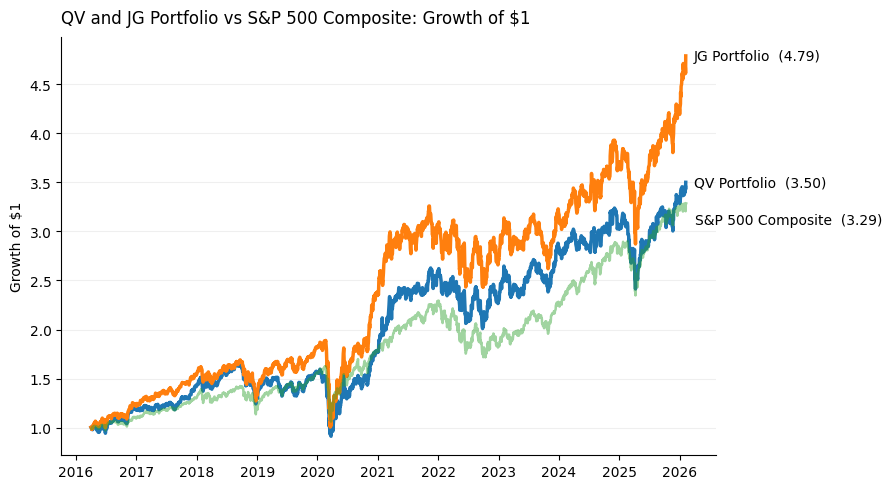

In [77]:
fig, ax = plt.subplots(figsize=(9, 5))

qv = portfolio_daily_return_qv_df['cum_return']
jg = portfolio_daily_return_jg_df['cum_return']
sp = sp_1500['cum_return']

# plots
ax.plot(qv.index, qv, linewidth=2.5, label="QV Portfolio")
ax.plot(jg.index, jg, linewidth=2.5, label="JG Portfolio")
ax.plot(sp.index,  sp,  linewidth=1.8, alpha=0.45, label="S&P 500 Composite")

# title and ax labels
ax.set_title("QV and JG Portfolio vs S&P 500 Composite: Growth of $1", loc="left", pad=10)
ax.set_ylabel("Growth of $1")

# no top and right spines and grid lines
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis="y", linewidth=0.8, alpha=0.2)
ax.grid(False, axis="x")

# labels at the end of line (ill use for the next graphs)
def label_last(ax, series, text, dx=5, dy=0):
    x_last = series.index[-1]
    y_last = series.iloc[-1]
    ax.annotate(
        f"{text}  ({y_last:.2f})",
        xy=(x_last, y_last),
        xytext=(dx, dy),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

# labels at the end of line
label_last(ax, qv, "QV Portfolio", dx=6, dy=0)
label_last(ax, jg, "JG Portfolio", dx=6, dy=0)
label_last(ax, sp,  "S&P 500 Composite", dx=6, dy=-12)

fig.tight_layout()
plt.show()

# Risk Metrics

Maximum drawdown

For the 10-year backtest, the maximum drawdown is the largest decline from QV and JG porftolio peak, (during those 10 years) to the lowest value reached after that peak and before a new peak is achieved.

The MDD for QV Portfolio is -44.99% and the JG Portfolio is -46.74%.

In [116]:
# maximum drawdown

def calc_max_drawdown(value_series):
    # value_series must be a series of the portfolio value in date order
    running_max_value = value_series.cummax() # cummax() (cumulative maximum), for each date it gives you the highest portfolio value seen so far
    drawdown = value_series / running_max_value - 1
    drawdown_min = drawdown.min()

    return drawdown_min, drawdown

max_dd_qv, drawdown_qv = calc_max_drawdown(portfolio_daily_return_qv_df['port_level'])
max_dd_jg, drawdown_jg = calc_max_drawdown(portfolio_daily_return_jg_df['port_level'])
max_dd_sp500, drawdown_sp500 = calc_max_drawdown(sp_500['last_close'])

print(f'Maximum Drawdown for QV Portfolio: {round(max_dd_qv * 100, 2)}%')
print(f'Maximum Drawdown for JG Portfolio: {round(max_dd_jg * 100, 2)}%')
print(f'Maximum Drawdown for S&P 500 Portfolio: {round(max_dd_sp500 * 100, 2)}%')

Maximum Drawdown for QV Portfolio: -44.99%
Maximum Drawdown for JG Portfolio: -46.74%
Maximum Drawdown for S&P 500 Portfolio: -33.92%


Drawdown Duration

For the 10-year backtest, the drawdown duration measures how long each portfolio stayed below its previous peak before recovering to a new high.

The drawdown duration for the QV Portfolio is 555 days.

The drawdown duration for the JG Portfolio is 579 days.

This means that at their worst period, the QV portfolio took 555 days to recover back to its previous peak, while the JG portfolio took 579 days to fully recover.

In [117]:
# drawdown duration

def calc_drawdown_duration(drawdown_series):
    # drawdown_series must be a series in date order
    underwater = drawdown_series < 0
    durations = underwater.groupby(
        (underwater != underwater.shift()).cumsum()
    ).sum()
    return durations.max()

dd_dur_qv = calc_drawdown_duration(drawdown_qv)
dd_dur_jg = calc_drawdown_duration(drawdown_jg)
dd_dur_sp500 = calc_drawdown_duration(drawdown_sp500)

print(f'Drawdown Duration QV Portfolio: {dd_dur_qv} days')
print(f'Drawdown Duration for JG Portfolio: {dd_dur_jg} days')
print(f'Drawdown Duration for JG Portfolio: {dd_dur_sp500} days')

Drawdown Duration QV Portfolio: 555 days
Drawdown Duration for JG Portfolio: 579 days
Drawdown Duration for JG Portfolio: 512 days


Worst Day Return

For the 10-year backtest, the worst day return is the largest single-day loss experienced by each portfolio during the period.

The worst day return for the QV Portfolio is -11.99% on 2020-03-16.

The worst day return for the JG Portfolio is -14.07% on 2020-03-16.

In [118]:
# worst day
def get_worst_day(return_series):
    worst_r = return_series.min()
    date = return_series.idxmin().date()
    return worst_r, date

worst_r_qv, w_date_qv = get_worst_day(portfolio_daily_return_qv_df['return'])
worst_r_jg, w_date_jg = get_worst_day(portfolio_daily_return_jg_df['return'])
worst_r_sp500, w_date_sp500 = get_worst_day(sp_500['daily_return'])

print(f'Worst Day Return for QV Portfolio: {round(worst_r_qv * 100, 2)}% on {w_date_qv}')
print(f'Worst Day Return for JG Portfolio: {round(worst_r_jg * 100, 2)}% on {w_date_jg}')
print(f'Worst Day Return for S&P 500: {round(worst_r_sp500 * 100, 2)}% on {w_date_sp500}')

Worst Day Return for QV Portfolio: -11.99% on 2020-03-16
Worst Day Return for JG Portfolio: -14.07% on 2020-03-16
Worst Day Return for S&P 500: -11.98% on 2020-03-16


Downside Deviation

For the 10-year backtest, downside deviation measures the volatility of only the returns under a minimum target return (I chose 0 as the MTR), meaning it focuses on harmful volatility rather than total volatility.

The downside deviation for the QV Portfolio is 0.98%.

The downside deviation for the JG Portfolio is 1.06%.

This means that during periods of negative returns, the JG portfolio experienced the most downside volatility.

In [81]:
# downside deviation

def calc_downside_deviation(returns_series, target=0):
    downside = np.minimum(returns_series - target, 0) #returns the minimum between returns_series row - target or 0
    down_dev = np.sqrt(np.mean(downside**2)) # square root of the average squared negative returns
    return down_dev

down_dev_qv = calc_downside_deviation(portfolio_daily_return_qv_df['return'], 0)
down_dev_jg = calc_downside_deviation(portfolio_daily_return_jg_df['return'], 0)
down_dev_sp500 = calc_downside_deviation(sp_500['daily_return'], 0)

print(f'Downside Deviation for QV Portfolio: {round(down_dev_qv * 100, 2)}%')
print(f'Downside Deviation Return for JG Portfolio: {round(down_dev_jg * 100, 2)}%')
print(f'Downside Deviation Return for S&P 500: {round(down_dev_sp500 * 100, 2)}%')

Downside Deviation for QV Portfolio: 0.98%
Downside Deviation Return for JG Portfolio: 1.06%
Downside Deviation Return for S&P 500: 0.81%


# Tail Risk metrics

Value at Risk (VaR) and Expected Shortfall

For the 10-year backtest, the 1-day 95% historical VaR represents the estimated maximum loss expected in a single day under normal market conditions, with 95% confidence.

The 1-day 95% historical VaR for the QV Portfolio is 1.96% loss.

The 1-day 95% historical VaR for the JG Portfolio is 2.17% loss.

This means that on 95% of trading days, the expected loss should not exceed these percentages, but in the worst 5% of days, losses could be larger.

For the 10-year backtest, the 1-day 95% Expected Shortfall measures the average loss on the worst 5% of days, meaning it shows how severe losses are when they exceed the VaR threshold.

The 1-day 95% Expected Shortfall for the QV Portfolio is 3.26% loss.

The 1-day 95% Expected Shortfall for the JG Portfolio is 3.46% loss.

This means that during the worst 5% of trading days, the JG portfolio experienced the largest average losses.

In [119]:
# var and cvar
def calc_var_cvar(returns_series, confidence=.95):
    returns = returns_series.dropna()
    percentile = 1 - confidence
    cutoff = returns.quantile(percentile)
    tail_losses = returns[returns <= cutoff]
    var = -cutoff
    cvar = -tail_losses.mean()
    return var, cvar

var_qv, cvar_qv = calc_var_cvar(portfolio_daily_return_qv_df['return'], .95)
var_jg, cvar_jg = calc_var_cvar(portfolio_daily_return_jg_df['return'], .95)
var_sp500, cvar_sp500 = calc_var_cvar(sp_500['daily_return'], .95)

print(f'The 1 day 95% historical VaR for QV Portfolio is: {round(var_qv * 100, 2)}% loss')
print(f'The 1 day 95% historical VaR for JG Portfolio is: {round(var_jg * 100, 2)}% loss')
print(f'The 1 day 95% historical VaR for S&P 500 is: {round(var_sp500 * 100, 2)}% loss')
print(f'The 1 day 95% Expected Shortfall for QV Portfolio is: {round(cvar_qv * 100, 2)}% loss')
print(f'The 1 day 95% Expected Shortfall for JG Portfolio is: {round(cvar_jg * 100, 2)}% loss')
print(f'The 1 day 95% Expected Shortfall for S&P 500 is: {round(cvar_sp500 * 100, 2)}% loss')

The 1 day 95% historical VaR for QV Portfolio is: 1.96% loss
The 1 day 95% historical VaR for JG Portfolio is: 2.17% loss
The 1 day 95% historical VaR for S&P 500 is: 1.67% loss
The 1 day 95% Expected Shortfall for QV Portfolio is: 3.26% loss
The 1 day 95% Expected Shortfall for JG Portfolio is: 3.46% loss
The 1 day 95% Expected Shortfall for S&P 500 is: 2.78% loss


In [120]:
# rolling 1 year window var and cvar
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

var_cvar_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    port_year_qv = portfolio_daily_return_qv_df.loc[(portfolio_daily_return_qv_df.index >= start_d) & (portfolio_daily_return_qv_df.index <= end_d)]
    var_qv, cvar_qv = calc_var_cvar(port_year_qv['return'], .95)

    port_year_jg = portfolio_daily_return_jg_df.loc[(portfolio_daily_return_jg_df.index >= start_d) & (portfolio_daily_return_jg_df.index <= end_d)]
    var_jg, cvar_jg = calc_var_cvar(port_year_jg['return'], .95)

    index_year = sp_500.loc[(sp_500.index >= start_d) & (sp_500.index <= end_d)]
    var_sp500, cvar_sp500 = calc_var_cvar(index_year['daily_return'], .95)

    var_cvar_by_year.append({
        'year': year,
        'var_95_qv': f'{round(var_qv * 100, 2)}%',
        'var_95_jg': f'{round(var_jg * 100, 2)}%',
        'var_95_sp500': f'{round(var_sp500 * 100, 2)}%',
        'cvar_95_qv': f'{round(cvar_sp500 * 100, 2)}%',
        'cvar_95_jg': f'{round(cvar_sp500 * 100, 2)}%',
        'cvar_95_sp500': f'{round(cvar_sp500 * 100, 2)}%',
    })

var_cvar_by_year_df = pd.DataFrame(var_cvar_by_year)

var_cvar_by_year_df

,year,var_95_qv,var_95_jg,var_95_sp500,cvar_95_qv,cvar_95_jg,cvar_95_sp500
0,2016,1.42%,1.3%,0.93%,1.56%,1.56%,1.56%
1,2017,1.08%,0.97%,0.54%,0.96%,0.96%,0.96%
2,2018,1.91%,2.16%,2.07%,2.75%,2.75%,2.75%
3,2019,1.72%,1.53%,1.19%,1.96%,1.96%,1.96%
4,2020,3.96%,3.79%,3.36%,5.54%,5.54%,5.54%
5,2021,1.76%,2.02%,1.31%,1.86%,1.86%,1.86%
6,2022,2.73%,2.81%,2.64%,3.35%,3.35%,3.35%
7,2023,1.64%,1.8%,1.38%,1.57%,1.57%,1.57%
8,2024,1.44%,1.87%,1.34%,1.89%,1.89%,1.89%
9,2025,1.83%,2.19%,1.61%,2.67%,2.67%,2.67%


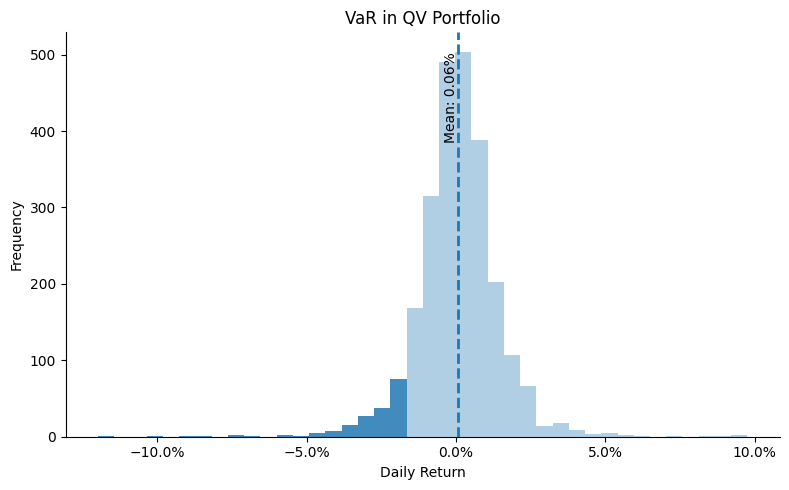

In [134]:
returns = portfolio_daily_return_qv_df['return']
mean = returns.mean()

left_tail_threshold = -var_qv # highlight days worse than var threshold

fig, ax = plt.subplots(figsize=(8, 5))

# plot histogram and capture patches so we can style specific bins
counts, bins, patches = ax.hist(returns, bins=40)

# highlight the left tail bins
for i, p in enumerate(patches):
    if bins[i] < left_tail_threshold:
        p.set_alpha(0.85)  # darker
    else:
        p.set_alpha(0.35)  # lighter

# mean line and label
ax.axvline(mean, linestyle='--', linewidth=2)
ax.text(
    mean, ax.get_ylim()[1] * 0.95,
    f"Mean: {mean:.2%}",
    rotation=90,
    va='top', ha='right'
)

#format x-axis as percent
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# looks better
ax.spines[['top', 'right']].set_visible(False)

# title and axes
ax.set_title("VaR in QV Portfolio")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

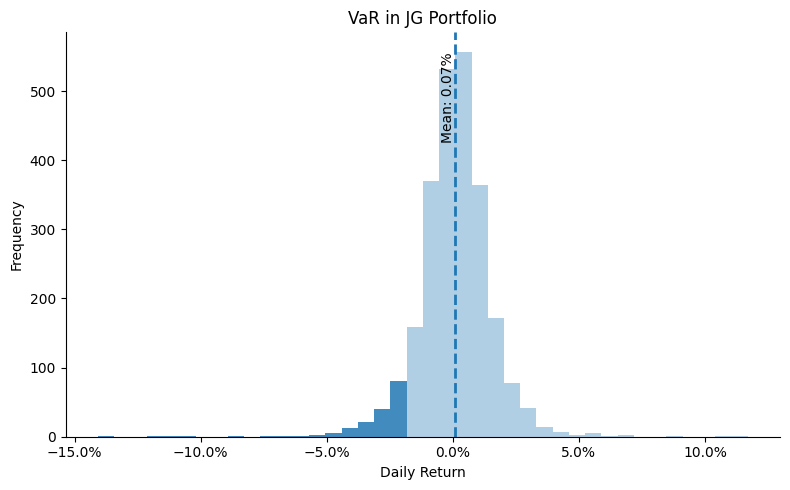

In [135]:
returns = portfolio_daily_return_jg_df['return']
mean = returns.mean()

left_tail_threshold = -var_jg # highlight days worse than var threshold

fig, ax = plt.subplots(figsize=(8, 5))

# plot histogram and capture patches so we can style specific bins
counts, bins, patches = ax.hist(returns, bins=40)

# highlight the left tail bins
for i, p in enumerate(patches):
    if bins[i] < left_tail_threshold:
        p.set_alpha(0.85)  # darker
    else:
        p.set_alpha(0.35)  # lighter

# mean line and label
ax.axvline(mean, linestyle='--', linewidth=2)
ax.text(
    mean, ax.get_ylim()[1] * 0.95,
    f"Mean: {mean:.2%}",
    rotation=90,
    va='top', ha='right'
)

#format x-axis as percent
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# looks better
ax.spines[['top', 'right']].set_visible(False)

# title and axes
ax.set_title("VaR in JG Portfolio")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Relative and systematic risk

In [123]:
# factor exposure data
factor_exposure_df = fama_french_5.copy()
factor_exposure_df['qv_return'] = portfolio_daily_return_qv_df['return'] * 100
factor_exposure_df['jg_return'] = portfolio_daily_return_jg_df['return'] * 100
factor_exposure_df['qv_excess_r'] = factor_exposure_df['qv_return'] - factor_exposure_df['RF']
factor_exposure_df['jg_excess_r'] = factor_exposure_df['jg_return'] - factor_exposure_df['RF']
factor_exposure_df.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF,qv_return,jg_return,qv_excess_r,jg_excess_r
date,,,,,,,,,,
2016-04-04,-0.41,-0.29,-0.78,-0.25,-0.20,0.0,-0.812694,-1.176539,-0.812694,-1.176539
2016-04-05,-0.94,-0.18,-0.38,0.09,0.17,0.0,-0.962925,-0.982602,-0.962925,-0.982602
2016-04-06,1.14,0.09,-0.76,-0.54,-0.65,0.0,0.972833,1.288066,0.972833,1.288066
2016-04-07,-1.23,-0.10,-0.38,-0.01,0.19,0.0,-1.409394,-0.996850,-1.409394,-0.996850
2016-04-08,0.29,0.13,0.68,0.37,0.31,0.0,0.259682,0.879002,0.259682,0.879002


OLS Regression Results (QV Portfolio)

For the 10-year backtest, an OLS regression was run on the QV portfolio excess returns using the Fama-French 5-factor model.

The R-squared is 0.929, which means that 92.9% of the portfolio’s excess return variation is explained by the five factors.

The intercept (alpha) is -0.0011, and it is not statistically significant (p = 0.850).
This means the portfolio does not generate statistically significant alpha after accounting for the factors.

The market beta (Mkt-RF) is 1.011, which means the QV portfolio has slightly higher sensitivity than the market.

The SMB loading is 0.770, meaning the portfolio has a strong tilt toward small-cap stocks.

The HML loading is 0.120, meaning the portfolio has a mild value exposure (at least measure by B/M ratio).

The RMW loading is 0.372, meaning the portfolio has a moderate profitability exposure.

The CMA loading is 0.167, but it is not statistically significant (p = 0.057), meaning the investment factor exposure is weak or borderline significant.

The F-statistic is significant (p = 0.00), meaning the model overall is statistically significant.

In [94]:
# factor exposure regression

# Factors
X = factor_exposure_df[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X = sm.add_constant(X)

y = factor_exposure_df['qv_excess_r']

# OLS
model_qv = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':63})

model_qv.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            qv_excess_r   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     1202.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:38:24   Log-Likelihood:                -1081.0
No. Observations:                2452   AIC:                             2174.
Df Residuals:                    2446   BIC:                             2209.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011      0.006     -0.189      0.850      -0.013       0.011
Mkt-RF         1.0110      0.016     61.678      0.000       0.979       1.043
SMB            0.7702      0.032     24.424      0.000       0.708       0.832
HML            0.1203      0.032      3.803      0.000       0.058       0.182
RMW            0.3720      0.030     12.544      0.000       0.314       0.430
CMA            0.1672      0.088      1.906      0.057      -0.005       0.339
==============================================================================
Omnibus:                     1230.395   Durbin-Watson:                   2.250
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           269977.189
Skew:                           1.217   Prob(JB):                         0.00
Kurtosis:                      54.348   Cond. No.                         3.27
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 63 lags and without small sample correction
"""

OLS Regression Results (JG Portfolio)

For the 10-year backtest, an OLS regression was run on the JG portfolio excess returns using the Fama-French 5-factor model.

The R-squared is 0.947, which means that 94.7% of the portfolio’s excess return variation is explained by the five factors.

The intercept (alpha) is 0.0092, and it is not statistically significant (p = 0.146).
This means the portfolio does not generate statistically significant alpha after accounting for the factors.

The market beta (Mkt-RF) is 1.086, which means the JG portfolio has higher market sensitivity than the market.

The SMB loading is 0.644, meaning the portfolio has a strong small-cap tilt.

The HML loading is 0.157, meaning the portfolio has moderate value exposure (at least measured by B/M ratio).

The RMW loading is -0.087, and it is statistically significant (p = 0.003), meaning the portfolio has a negative profitability exposure.

The CMA loading is 0.064, and it is not statistically significant (p = 0.221), meaning the investment factor exposure is weak.

The F-statistic is significant (p = 0.00), meaning the model overall is statistically significant.

In [95]:
# factor exposure regression
y = factor_exposure_df['jg_excess_r']

# OLS
model_jg = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':63})

model_jg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            jg_excess_r   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     2620.
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:38:26   Log-Likelihood:                -866.88
No. Observations:                2452   AIC:                             1746.
Df Residuals:                    2446   BIC:                             1781.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0092      0.006      1.454      0.146      -0.003       0.022
Mkt-RF         1.0856      0.013     81.999      0.000       1.060       1.112
SMB            0.6436      0.025     25.439      0.000       0.594       0.693
HML            0.1568      0.030      5.162      0.000       0.097       0.216
RMW           -0.0869      0.029     -2.957      0.003      -0.145      -0.029
CMA            0.0637      0.052      1.225      0.221      -0.038       0.166
==============================================================================
Omnibus:                      260.954   Durbin-Watson:                   1.917
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1816.147
Skew:                          -0.230   Prob(JB):                         0.00
Kurtosis:                       7.191   Cond. No.                         3.27
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 63 lags and without small sample correction
"""

In [99]:
# Factor exposure over years
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

factor_exposure_qv_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    factor_exp_df = factor_exposure_df.loc[(factor_exposure_df.index >= start_d) & (factor_exposure_df.index <= end_d)]
    # Factors
    X = factor_exp_df[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    X = sm.add_constant(X)

    y = factor_exp_df['qv_excess_r']

    # OLS
    model_qv = sm.OLS(y, X).fit()
    betas = model_qv.params

    factor_exposure_qv_by_year.append({
        'year': year,
        'beta_mkt': model_qv.params['Mkt-RF'],
        'beta_smb': model_qv.params["SMB"],
        'beta_hml': model_qv.params["HML"],
        'beta_rmw': model_qv.params["RMW"],
        'beta_cma': model_qv.params["CMA"]
    })

factor_exposure_qv_by_year_df = pd.DataFrame(factor_exposure_qv_by_year)

factor_exposure_qv_by_year_df


,year,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma
0,2016,1.098420,0.640897,0.079614,0.260553,0.070935
1,2017,1.019546,0.680345,-0.035372,0.441583,0.305927
2,2018,1.035459,0.694487,0.014702,0.308426,0.243030
3,2019,1.063264,0.702107,0.169196,0.421380,0.005132
4,2020,0.971869,0.689077,0.236219,0.445108,-0.021217
5,2021,0.760580,0.802833,-0.090009,0.318639,0.926596
6,2022,1.080643,0.892249,0.201172,0.267006,0.049629
7,2023,0.999894,0.733395,0.031769,0.347062,0.127752
8,2024,0.910479,0.677648,0.148042,0.302587,0.103682
9,2025,1.023869,0.908593,0.119476,0.460981,0.270847


In [100]:
# Factor exposure over years
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

factor_exposure_jg_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    factor_exp_df = factor_exposure_df.loc[(factor_exposure_df.index >= start_d) & (factor_exposure_df.index <= end_d)]
    # Factors
    X = factor_exp_df[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    X = sm.add_constant(X)

    y = factor_exp_df['jg_excess_r']

    # OLS
    model_qv = sm.OLS(y, X).fit()
    betas = model_qv.params

    factor_exposure_jg_by_year.append({
        'year': year,
        'beta_mkt': model_qv.params['Mkt-RF'],
        'beta_smb': model_qv.params["SMB"],
        'beta_hml': model_qv.params["HML"],
        'beta_rmw': model_qv.params["RMW"],
        'beta_cma': model_qv.params["CMA"]
    })

factor_exposure_jg_by_year_df = pd.DataFrame(factor_exposure_jg_by_year)

factor_exposure_jg_by_year_df

,year,beta_mkt,beta_smb,beta_hml,beta_rmw,beta_cma
0,2016,1.193855,0.464370,0.066992,0.079527,0.360839
1,2017,1.103492,0.480792,-0.155076,-0.093430,0.361576
2,2018,1.046751,0.540761,-0.052662,-0.114177,0.256800
3,2019,1.049076,0.542977,0.092108,0.012624,0.015280
4,2020,1.045933,0.714691,0.266085,0.119799,-0.294588
5,2021,1.121389,0.604511,0.244076,-0.232636,-0.023998
6,2022,1.084338,0.657358,0.132402,-0.188384,0.067535
7,2023,1.047257,0.614052,0.142857,-0.077390,0.166083
8,2024,1.026941,0.582371,0.081037,-0.018320,0.153388
9,2025,1.105507,0.638577,0.054535,-0.067169,0.164126


In [125]:
# tracking error
def calc_ann_tracking_error(returns_series, benchmark_returns):
    active = returns_series - benchmark_returns
    tracking_e_daily = active.std()
    tracking_e_annual = tracking_e_daily * (252 ** 0.5)
    return tracking_e_daily, tracking_e_annual

te_daily_qv, te_ann_qv = calc_ann_tracking_error(portfolio_daily_return_qv_df['return'], sp_500['daily_return'])
te_daily_jg, te_ann_jg = calc_ann_tracking_error(portfolio_daily_return_jg_df['return'], sp_500['daily_return'])

print(f'Tracking Error Annual for QV Portfolio: {round(te_ann_qv * 100, 2)}%')
print(f'Tracking Error Annual for JG Portfolio: {round(te_ann_jg * 100, 2)}%')

Tracking Error Annual for QV Portfolio: 12.05%
Tracking Error Annual for JG Portfolio: 11.47%


# Risk-adjusted Returns

Sharpe Ratio

For the 10-year backtest, the Sharpe ratio measures risk-adjusted return by comparing excess return to volatility.

The Sharpe ratio for the QV portfolio is 0.555.

The Sharpe ratio for the JG portfolio is 0.644.

This means that over the full period, the JG portfolio delivered higher return per unit of risk than QV.

Year-by-year results show that JG performed significantly better during strong market years, while QV performed relatively better during weaker market periods.

In [138]:
# Convert percent to decimal
qv_excess = factor_exposure_df['qv_excess_r'] / 100
jg_excess = factor_exposure_df['jg_excess_r'] / 100

# QV Sharpe
sharpe_qv = (qv_excess.mean() / qv_excess.std()) * np.sqrt(252)

# JG Sharpe
sharpe_jg = (jg_excess.mean() / jg_excess.std()) * np.sqrt(252)

print("QV Sharpe:", round(sharpe_qv, 3))
print("JG Sharpe:", round(sharpe_jg, 3))


QV Sharpe: 0.555
JG Sharpe: 0.644


In [139]:
# Factor exposure over years
years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

sharpe_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    factor_exp_df = factor_exposure_df.loc[(factor_exposure_df.index >= start_d) & (factor_exposure_df.index <= end_d)]
    
    qv_excess = factor_exp_df['qv_excess_r'] / 100
    jg_excess = factor_exp_df['jg_excess_r'] / 100

    sharpe_qv = (qv_excess.mean() / qv_excess.std()) * np.sqrt(252)
    sharpe_jg = (jg_excess.mean() / jg_excess.std()) * np.sqrt(252)

    sharpe_by_year.append({
        'year': year,
        'sharpe_qv': sharpe_qv,
        'sharpe_jg': sharpe_jg,
    })

sharpe_by_year_df = pd.DataFrame(sharpe_by_year)

sharpe_by_year_df

,year,sharpe_qv,sharpe_jg
0,2016,1.448791,1.640171
1,2017,1.719339,2.169082
2,2018,-0.452697,-0.736260
3,2019,0.950573,1.802030
4,2020,0.504382,0.824297
5,2021,1.860755,1.224652
6,2022,-0.348035,-0.303429
7,2023,1.018018,0.692712
8,2024,0.165845,0.526533
9,2025,0.243024,0.508893
